## I. Data preparation

### Imports

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns
from autocorrect import Speller
import warnings
warnings.filterwarnings('ignore')

In [3]:
nltk.download('popular')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/jyanadio/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/jyanadio/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/jyanadio/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/jyanadio/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/jyanadio/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/jyanadio/nltk_data...
[nltk_data]    |   Package movie_reviews is a

True

### Get data

In [4]:
df_pos = pd.read_csv('data/processedPositive.csv')
df_neg = pd.read_csv('data/processedNegative.csv')
df_neu = pd.read_csv('data/processedNeutral.csv')

In [5]:
df_pos.head()

,An inspiration in all aspects: Fashion,fitness,beauty and personality. :)KISSES TheFashionIcon,Apka Apna Awam Ka Channel Frankline Tv Aam Admi Production Please Visit Or Likes Share :)Fb Page :...,Beautiful album from the greatest unsung guitar genius of our time - and I've met the great backstage,Good luck to Rich riding for great project in this Sunday. Can you donate?,Omg he... kissed... him crying with joy,happy anniv ming and papi!!!!! love love happy,thanks happy,C'mon Tweeps,...,$ES_F $SPY Bulls are just relentless happy Some setups I like today,Thanks for the recent follow Happy to connect happy have a great Thursday..33,Thanks for the recent follow Happy to connect happy have a great Thursday. Want this.5,Thanks for the recent follow Happy to connect happy have a great Thursday. Want this.7,you know that the problem still exist :D,Thanks for the recent follow Happy to connect happy have a great Thursday. Get this.1,- top engaged members this week happy,ngam to weeks left for cadet pilot exam crying with joy,Great! You're welcome Josh happy ^Adam,Sixth spot not applicable Team! Higher pa! :)KISSES TheFashionIcon.4


### Transposition and joining

In [6]:
def df_preparation(df: pd.DataFrame, target_value: int):
    df_new = df.T.reset_index().rename(columns={'index': 'tweet'})
    df_new['target'] = target_value
    return df_new

In [7]:
df_neg = df_preparation(df_neg, -1)
df_neu = df_preparation(df_neu, 0)
df_pos = df_preparation(df_pos, 1)
df = pd.concat([df_neg, df_neu, df_pos], ignore_index=True)

In [8]:
df.duplicated().sum()

np.int64(0)

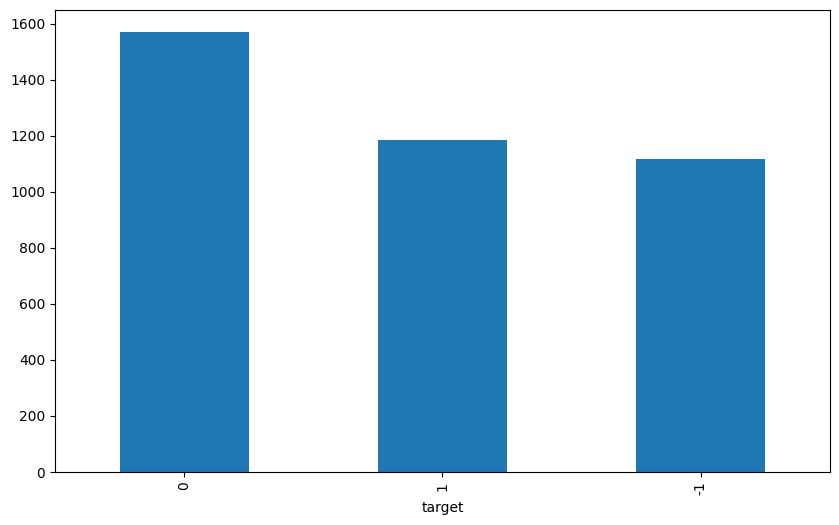

In [9]:
plt.figure(figsize=(10, 6))
df.target.value_counts().plot(kind='bar')
plt.show()

### Data operating

In [10]:
def standardize_text(df, text_field):
    df[text_field] = df[text_field].str.replace(r"http", "")
    df[text_field] = df[text_field].str.replace(r'[^a-zA-Z ]', '', regex=True)
    df[text_field] = df[text_field].str.replace(r"@\w+", "", regex=True)
    df[text_field] = df[text_field].str.strip()
    df[text_field] = df[text_field].str.lower()
    return df

In [11]:
df = standardize_text(df, 'tweet')

In [12]:
tokenizer = RegexpTokenizer(r'\w+')

df["tokens"] = df["tweet"].apply(tokenizer.tokenize)
df.head()

,tweet,target,tokens
0,how unhappy some dogs like it though,-1,"[how, unhappy, some, dogs, like, it, though]"
1,talking to my over driver about where im going...,-1,"[talking, to, my, over, driver, about, where, ..."
2,does anybody know if the rands likely to fall ...,-1,"[does, anybody, know, if, the, rands, likely, ..."
3,i miss going to gigs in liverpool unhappy,-1,"[i, miss, going, to, gigs, in, liverpool, unha..."
4,there isnt a new riverdale tonight unhappy,-1,"[there, isnt, a, new, riverdale, tonight, unha..."


In [13]:
all_words = [word for tokens in df["tokens"] for word in tokens]
tweet_lengths = [len(tokens) for tokens in df["tokens"]]
VOCAB = sorted(list(set(all_words)))
print("%s words total, with a vocabulary size of %s" % (len(all_words), len(VOCAB)))
print("Max sentence length is %s" % max(tweet_lengths))

33208 words total, with a vocabulary size of 6378
Max sentence length is 30


### Vectorization techniques

In [14]:
def binarize(df, tokens_column, target_column, test_size=0.2):
    '''
    Binarize, split stratified and return X_train, X_test, y_train, y_test
    '''
    X_train, X_test, y_train, y_test = train_test_split(df[tokens_column], df[target_column],
                                                        stratify=df[target_column], test_size=test_size, random_state=21)

    mlb = MultiLabelBinarizer()
    mlb.fit(X_train)
    X_train_bin = mlb.transform(X_train)
    X_test_bin = mlb.transform(X_test)
    # binarized = pd.DataFrame(data=mlb.fit_transform(df[tokens_column]), columns=mlb.classes_)
    return X_train_bin, X_test_bin, y_train, y_test

In [15]:
def word_counts(df, tokens_column, target_column, test_size=0.2):
    '''
    Count vectorize, split stratified and return X_train, X_test, y_train, y_test
    '''
    list_corpus = df[tokens_column].apply(lambda x: ' '.join(x)).tolist()
    list_labels = df[target_column].tolist()

    X_train, X_test, y_train, y_test = train_test_split(list_corpus, list_labels, stratify=list_labels, test_size=test_size, random_state=21)

    count_vectorizer = CountVectorizer()
    X_train_counts = count_vectorizer.fit_transform(X_train)
    X_test_counts = count_vectorizer.transform(X_test)

    return X_train_counts, X_test_counts, y_train, y_test

In [16]:
def tfidf(df, tokens_column, target_column, test_size=0.2):
    '''
    tfidf vectorize, split stratified and return X_train, X_test, y_train, y_test
    '''
    list_corpus = df[tokens_column].apply(lambda x: ' '.join(x)).tolist()
    list_labels = df[target_column].tolist()

    X_train, X_test, y_train, y_test = train_test_split(list_corpus, list_labels, stratify=list_labels, test_size=test_size, random_state=21)
    tfidf = TfidfVectorizer()
    tfidf.fit(X_train)
    X_train_tfidf = tfidf.transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    return X_train_tfidf, X_test_tfidf, y_train, y_test

### Preprocessing techniques

In [17]:
def lemming(df, tokens_column):
    lemmatizer = WordNetLemmatizer()
    return df[tokens_column].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

def stemming(df, tokens_column):
    stemmer = PorterStemmer()
    return df[tokens_column].apply(lambda x: [stemmer.stem(word) for word in x])

def stop_words_remove(df, tokens_column):
    stop_words = set(stopwords.words('english'))
    return df[tokens_column].apply(lambda x: [word for word in x if word not in stop_words])

def misspelling(df, tokens_column):
    speller = Speller(lang="en")
    return df[tokens_column].apply(lambda words: [speller(word) for word in words])

In [18]:
df['stemming'] = stemming(df, 'tokens')

df['lemmatization'] = lemming(df, 'tokens')

df['misspelling'] = misspelling(df, 'tokens')
df['stemming+misspellings'] = stemming(df, 'misspelling')

#df['misspelling'] = misspelling(df, 'tokens')
df['lemmatization+misspellings'] = lemming(df, 'misspelling')

df['stop_words'] = stop_words_remove(df, 'tokens')

KeyboardInterrupt: 

In [ ]:
def find_top_similar_pairs(df, tokens_column, vectorizer_type='', n=10):
    texts = df[tokens_column].apply(lambda x: ' '.join(x)).tolist()
    labels = df['target'].tolist() 
    
    if vectorizer_type == 'binarize':
        mlb = MultiLabelBinarizer()
        vectors = mlb.fit_transform(df[tokens_column])
        
    elif vectorizer_type == 'word_counts':
        list_corpus = df[tokens_column].apply(lambda x: ' '.join(x)).tolist()
        count_vectorizer = CountVectorizer()
        vectors = count_vectorizer.fit_transform(list_corpus)
        
    elif vectorizer_type == 'tfidf':
        list_corpus = df[tokens_column].apply(lambda x: ' '.join(x)).tolist()
        tfidf_vectorizer = TfidfVectorizer()
        vectors = tfidf_vectorizer.fit_transform(list_corpus)
    
    else:
        raise ValueError("vectorizer_type must be 'binarize', 'word_counts', or 'tfidf'")
    
    similarity_matrix = cosine_similarity(vectors)
    
    pairs = []
    for i in range(len(similarity_matrix)):
        for j in range(i + 1, len(similarity_matrix)):
            if similarity_matrix[i, j] < 0.999:
                pairs.append((i, j, similarity_matrix[i, j]))
    
    pairs.sort(key=lambda x: x[2], reverse=True)
    
    print(f"\n{'='*80}")
    print(f"Top {n} similar tweets using {vectorizer_type} and {tokens_column})")
    print(f"{'='*80}\n")
    
    for k, (i, j, score) in enumerate(pairs[:n], 1):
        print(f"Pait #{k} | Similarity: {score:.4f}")
        print(f"\t-{texts[i][:150]}...")
        print(f"\t-{texts[j][:150]}...")
        print("-" * 80)
    
    return pairs[:n]

In [ ]:
find_top_similar_pairs(df, 'tokens', vectorizer_type='tfidf', n=10)


Top 10 similar tweets using tfidf and tokens)

Pait #1 | Similarity: 0.9950
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number cont...
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number for cont...
--------------------------------------------------------------------------------
Pait #2 | Similarity: 0.9950
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number for cont...
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number cont...
--------------------------------------------------------------------------------
Pait #3 | Similarity: 0.9819
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number for cont...
	-hi we tried to call your number but got no r

[(774, 865, np.float64(0.9950432611924166)),
 (865, 1043, np.float64(0.9950432611924166)),
 (865, 1014, np.float64(0.9818806920464735)),
 (2719, 3146, np.float64(0.9781719403589922)),
 (3146, 3771, np.float64(0.9781719403589922)),
 (3146, 3792, np.float64(0.9781719403589922)),
 (774, 1014, np.float64(0.9770869327442301)),
 (1014, 1043, np.float64(0.9770869327442301)),
 (1205, 2534, np.float64(0.9625657953255438)),
 (1138, 2618, np.float64(0.9553001990391468))]

In [ ]:
find_top_similar_pairs(df, 'stemming', vectorizer_type='binarize', n=10)


Top 10 similar tweets using binarize and stemming)

Pait #1 | Similarity: 0.9780
	-hi we tri to call your number but got no respons unhappi pleas share anoth suitabl time and an altern number for cont...
	-hi we tri to call your number but got no respons unhappi pleas share anoth suitabl time and an altern number for us to cont...
--------------------------------------------------------------------------------
Pait #2 | Similarity: 0.9770
	-hi ashish we tri to call your number but got no respons unhappi pleas share anoth suitabl time and an altern cont...
	-hi we tri to call your number but got no respons unhappi pleas share anoth suitabl time and an altern number cont...
--------------------------------------------------------------------------------
Pait #3 | Similarity: 0.9770
	-hi ashish we tri to call your number but got no respons unhappi pleas share anoth suitabl time and an altern cont...
	-hi we tri to call your number but got no respons unhappi pleas share anoth suitabl time

[(865, 1014, np.float64(0.9780192938436517)),
 (565, 774, np.float64(0.9770084209183943)),
 (565, 1043, np.float64(0.9770084209183943)),
 (774, 865, np.float64(0.9770084209183943)),
 (865, 1043, np.float64(0.9770084209183943)),
 (2708, 3435, np.float64(0.9636241116594317)),
 (2719, 3146, np.float64(0.9636241116594316)),
 (3146, 3771, np.float64(0.9636241116594316)),
 (3146, 3792, np.float64(0.9636241116594316)),
 (3153, 3346, np.float64(0.9636241116594316))]

In [ ]:
find_top_similar_pairs(df, 'misspelling', vectorizer_type='word_counts', n=10)


Top 10 similar tweets using word_counts and misspelling)

Pait #1 | Similarity: 0.9798
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number cont...
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number for cont...
--------------------------------------------------------------------------------
Pait #2 | Similarity: 0.9798
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number for cont...
	-hi we tried to call your number but got no response unhappy please share another suitable time and an alternate number cont...
--------------------------------------------------------------------------------
Pait #3 | Similarity: 0.9701
	-hey thanks for being top new followers this week much appreciated happy want this...
	-hey thanks for being my top new followers this week much appreciated happy want

[(774, 865, np.float64(0.9797958971132712)),
 (865, 1043, np.float64(0.9797958971132712)),
 (2719, 3146, np.float64(0.9701425001453321)),
 (3146, 3771, np.float64(0.9701425001453321)),
 (3146, 3792, np.float64(0.9701425001453321)),
 (865, 1014, np.float64(0.96561575852067)),
 (58, 325, np.float64(0.9636241116594316)),
 (58, 515, np.float64(0.9636241116594316)),
 (163, 325, np.float64(0.9636241116594316)),
 (163, 515, np.float64(0.9636241116594316))]

### Serching best settings

In [ ]:
def run_grid(model, param_grid, X_train, y_train, X_test, y_test, cv=5):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    
    print(grid.best_params_)
    print(grid.best_score_)
    print(accuracy_score(y_test, grid.best_estimator_.predict(X_test)))
    
    return grid.best_estimator_  

In [ ]:
X_train, X_test, y_train, y_test = tfidf(df, 'tokens', 'target')

logreg_params = {
    'C': [0.1, 1, 10, 30],
    'solver': ['lbfgs', 'liblinear', 'newton_cg'],
    'max_iter': [100, 200, 500],
    'class_weight': ['balanced', None]
}

print("=== Logistic Regression ===")
clf = run_grid(
    LogisticRegression(random_state=21),
    logreg_params,
    X_train, y_train, X_test, y_test,
    cv=5
)


=== Logistic Regression ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits
{'C': 30, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'liblinear'}
0.8824972640575328
0.8903225806451613


In [ ]:
results_logreg = pd.DataFrame({'preprocces':[], '0 or 1 if the word exists': [], 'word counts':[], 'TFIDF':[]})
     

In [ ]:
def make_classification(prep_name, df, tokens_column, target_column, model):
    result = [prep_name]
    X_train, X_test, y_train, y_test = binarize(df, tokens_column, target_column)
    model.fit(X_train, y_train)
    result.append(accuracy_score(y_test, model.predict(X_test)))

    X_train, X_test, y_train, y_test = word_counts(df, tokens_column, target_column)
    model.fit(X_train, y_train)
    result.append(accuracy_score(y_test, model.predict(X_test)))

    X_train, X_test, y_train, y_test = tfidf(df, tokens_column, target_column)
    model.fit(X_train, y_train)
    result.append(accuracy_score(y_test, model.predict(X_test)))

    return result

In [ ]:
results_logreg.loc[len(results_logreg)] = make_classification('just tokenization', df, 'tokens', 'target', clf)

results_logreg.loc[len(results_logreg)] = make_classification('stemming', df, 'stemming', 'target', clf)

results_logreg.loc[len(results_logreg)] = make_classification('lemmatization', df, 'lemmatization', 'target', clf)

results_logreg.loc[len(results_logreg)] = make_classification('stemming+misspellings', df, 'stemming+misspellings', 'target', clf)

results_logreg.loc[len(results_logreg)] = make_classification('lemmatization+misspellings', df, 'lemmatization+misspellings', 'target', clf)

results_logreg.loc[len(results_logreg)] = make_classification('stop_words', df, 'stop_words', 'target', clf)
     

In [ ]:
results_logreg

,preprocces,0 or 1 if the word exists,word counts,TFIDF
0,just tokenization,0.899355,0.887742,0.890323
1,stemming,0.901935,0.883871,0.895484
2,lemmatization,0.896774,0.883871,0.892903
3,stemming+misspellings,0.895484,0.880000,0.895484
4,lemmatization+misspellings,0.895484,0.886452,0.895484
5,stop_words,0.887742,0.889032,0.892903


In [ ]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("\n=== Random Forest ===")
rf = run_grid(
    RandomForestClassifier(random_state=21),
    rf_params,
    X_train, y_train, X_test, y_test,
    cv=3
)


=== Random Forest ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
0.8776618364013397
0.8890322580645161


In [ ]:
results_rf = pd.DataFrame({'preprocces':[], '0 or 1 if the word exists': [], 'word counts':[], 'TFIDF':[]})

In [ ]:
results_rf.loc[len(results_rf)] = make_classification('just tokenization', df, 'tokens', 'target', rf)

results_rf.loc[len(results_rf)] = make_classification('stemming', df, 'stemming', 'target',rf)

results_rf.loc[len(results_rf)] = make_classification('lemmatization', df, 'lemmatization', 'target', rf)

results_rf.loc[len(results_rf)] = make_classification('stemming+misspellings', df, 'stemming+misspellings', 'target', rf)

results_rf.loc[len(results_rf)] = make_classification('lemmatization+misspellings', df, 'lemmatization+misspellings', 'target', rf)

results_rf.loc[len(results_rf)] = make_classification('stop_words', df, 'stop_words', 'target', rf)

In [ ]:
results_rf

,preprocces,0 or 1 if the word exists,word counts,TFIDF
0,just tokenization,0.899355,0.885161,0.885161
1,stemming,0.894194,0.886452,0.885161
2,lemmatization,0.891613,0.885161,0.877419
3,stemming+misspellings,0.895484,0.883871,0.891613
4,lemmatization+misspellings,0.891613,0.885161,0.885161
5,stop_words,0.880000,0.878710,0.881290
